# 🫀 Heart Disease Risk Prediction — End-to-End Pipeline
**Dataset:** UCI Heart Disease (Cleveland + Hungary + Switzerland + VA Long Beach)  
**Target:** Heart Disease Presence (0 = No Disease / 1 = Disease)  

---
## Pipeline Steps
1. Data Understanding  
2. Data Cleaning  
3. Exploratory Data Analysis (EDA)  
4. Data Preprocessing  
5. Feature Engineering  
6. Model Building & Evaluation  
7. Model Selection  
8. Visualisations  
9. Final Output  
10. BONUS — Digital Twin  
11. Insights & Limitations  


## Step 0 — Imports & Configuration

In [35]:
import warnings
warnings.filterwarnings("ignore")

import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing   import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model    import LogisticRegression
from sklearn.tree            import DecisionTreeClassifier
from sklearn.ensemble        import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.impute          import SimpleImputer
from sklearn.metrics         import (accuracy_score, precision_score, recall_score,
                                     f1_score, roc_auc_score, confusion_matrix,
                                     ConfusionMatrixDisplay, classification_report,
                                     roc_curve, auc)

# Style — نفس style الملف الاصلي
PALETTE = {0: "#2ecc71", 1: "#e74c3c", "0": "#2ecc71", "1": "#e74c3c"}
LABELS  = {0: "No Disease", 1: "Disease"}
sns.set_theme(style="whitegrid", font_scale=1.05)
plt.rcParams.update({"figure.dpi": 130,
                      "axes.spines.top": False,
                      "axes.spines.right": False})
print("✅ Libraries loaded successfully")

✅ Libraries loaded successfully


## Step 1 — Data Understanding

In [36]:
df_raw = pd.read_csv("heart_disease_uci.csv")
print(f"Shape : {df_raw.shape[0]:,} rows x {df_raw.shape[1]} columns")
print("\nColumn Names:")
print(list(df_raw.columns))

Shape : 920 rows x 16 columns

Column Names:
['id', 'age', 'sex', 'dataset', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num']


In [37]:
print("Data Types:")
print(df_raw.dtypes.to_string())

Data Types:
id            int64
age           int64
sex          object
dataset      object
cp           object
trestbps    float64
chol        float64
fbs          object
restecg      object
thalch      float64
exang        object
oldpeak     float64
slope        object
ca          float64
thal         object
num           int64


In [38]:
print("Missing Values (%%):")
print((df_raw.isnull().mean()*100).round(2).to_string())

Missing Values (%%):
id           0.00
age          0.00
sex          0.00
dataset      0.00
cp           0.00
trestbps     6.41
chol         3.26
fbs          9.78
restecg      0.22
thalch       5.98
exang        5.98
oldpeak      6.74
slope       33.59
ca          66.41
thal        52.83
num          0.00


In [39]:
df_raw.describe().round(2)

,id,age,trestbps,chol,thalch,oldpeak,ca,num
count,920.00,920.00,861.00,890.00,865.00,858.00,309.00,920.00
mean,460.50,53.51,132.13,199.13,137.55,0.88,0.68,1.00
std,265.73,9.42,19.07,110.78,25.93,1.09,0.94,1.14
min,1.00,28.00,0.00,0.00,60.00,-2.60,0.00,0.00
25%,230.75,47.00,120.00,175.00,120.00,0.00,0.00,0.00
50%,460.50,54.00,130.00,223.00,140.00,0.50,0.00,1.00
75%,690.25,60.00,140.00,268.00,157.00,1.50,1.00,2.00
max,920.00,77.00,200.00,603.00,202.00,6.20,3.00,4.00


In [40]:
print("Target Distribution (num):")
print(df_raw["num"].value_counts())
print("\nBinary Target (0=No Disease, 1=Disease):")
print((df_raw["num"] > 0).astype(int).value_counts())

Target Distribution (num):
num
0    411
1    265
2    109
3    107
4     28
Name: count, dtype: int64

Binary Target (0=No Disease, 1=Disease):
num
1    509
0    411
Name: count, dtype: int64


In [41]:
feat_desc = {
    "age"      : "Patient age in years",
    "sex"      : "Biological sex (Male/Female)",
    "dataset"  : "Medical center (Cleveland/Hungary/Switzerland/VA Long Beach)",
    "cp"       : "Chest pain type (0=Typical Angina, 1=Atypical, 2=Non-anginal, 3=Asymptomatic)",
    "trestbps" : "Resting blood pressure (mmHg)",
    "chol"     : "Serum cholesterol (mg/dL)",
    "fbs"      : "Fasting blood sugar > 120 mg/dL (1=True)",
    "restecg"  : "Resting ECG results (0-2)",
    "thalch"   : "Maximum heart rate achieved",
    "exang"    : "Exercise induced angina (1=Yes)",
    "oldpeak"  : "ST depression induced by exercise relative to rest",
    "slope"    : "Slope of the peak exercise ST segment",
    "ca"       : "Number of major vessels colored by fluoroscopy (0-3)",
    "thal"     : "Thalassemia type (Normal/Fixed Defect/Reversable Defect)",
    "num"      : "TARGET: Heart disease diagnosis (0=No, 1-4=Yes)",
}
for k, v in feat_desc.items():
    print(f"  {k:<12} -> {v}")

  age          -> Patient age in years
  sex          -> Biological sex (Male/Female)
  dataset      -> Medical center (Cleveland/Hungary/Switzerland/VA Long Beach)
  cp           -> Chest pain type (0=Typical Angina, 1=Atypical, 2=Non-anginal, 3=Asymptomatic)
  trestbps     -> Resting blood pressure (mmHg)
  chol         -> Serum cholesterol (mg/dL)
  fbs          -> Fasting blood sugar > 120 mg/dL (1=True)
  restecg      -> Resting ECG results (0-2)
  thalch       -> Maximum heart rate achieved
  exang        -> Exercise induced angina (1=Yes)
  oldpeak      -> ST depression induced by exercise relative to rest
  slope        -> Slope of the peak exercise ST segment
  ca           -> Number of major vessels colored by fluoroscopy (0-3)
  thal         -> Thalassemia type (Normal/Fixed Defect/Reversable Defect)
  num          -> TARGET: Heart disease diagnosis (0=No, 1-4=Yes)


## Step 2 — Data Cleaning

In [42]:
df = df_raw.copy()

# Binary target
df["target"] = (df["num"] > 0).astype(int)
df.drop(columns=["num", "id"], inplace=True, errors="ignore")

# Remove duplicates
before = len(df)
df = df.drop_duplicates()
print(f"Duplicates removed : {before - len(df)}")

# Encode categoricals
le = LabelEncoder()
for col in ["sex", "dataset", "cp", "restecg", "slope", "thal"]:
    df[col] = le.fit_transform(df[col].astype(str))
df["exang"] = df["exang"].map({True:1, False:0, "TRUE":1, "FALSE":0}).fillna(0)
df["fbs"]   = df["fbs"].map({True:1, False:0, "TRUE":1, "FALSE":0}).fillna(0)

# Impute missing values with median
num_cols = df.select_dtypes(include=np.number).columns.tolist()
for c in num_cols:
    df[c] = df[c].fillna(df[c].median())

print(f"Missing values after imputation: {df.isnull().sum().sum()}")
print(f"Shape after cleaning: {df.shape}")
print(f"\nTarget distribution:")
print(f"  No Disease: {(df.target==0).sum()} ({(df.target==0).mean()*100:.1f}%%)")
print(f"  Disease:    {(df.target==1).sum()} ({(df.target==1).mean()*100:.1f}%%)")

Duplicates removed : 2
Missing values after imputation: 0
Shape after cleaning: (918, 15)

Target distribution:
  No Disease: 410 (44.7%%)
  Disease:    508 (55.3%%)


## Step 3 — Exploratory Data Analysis (EDA)

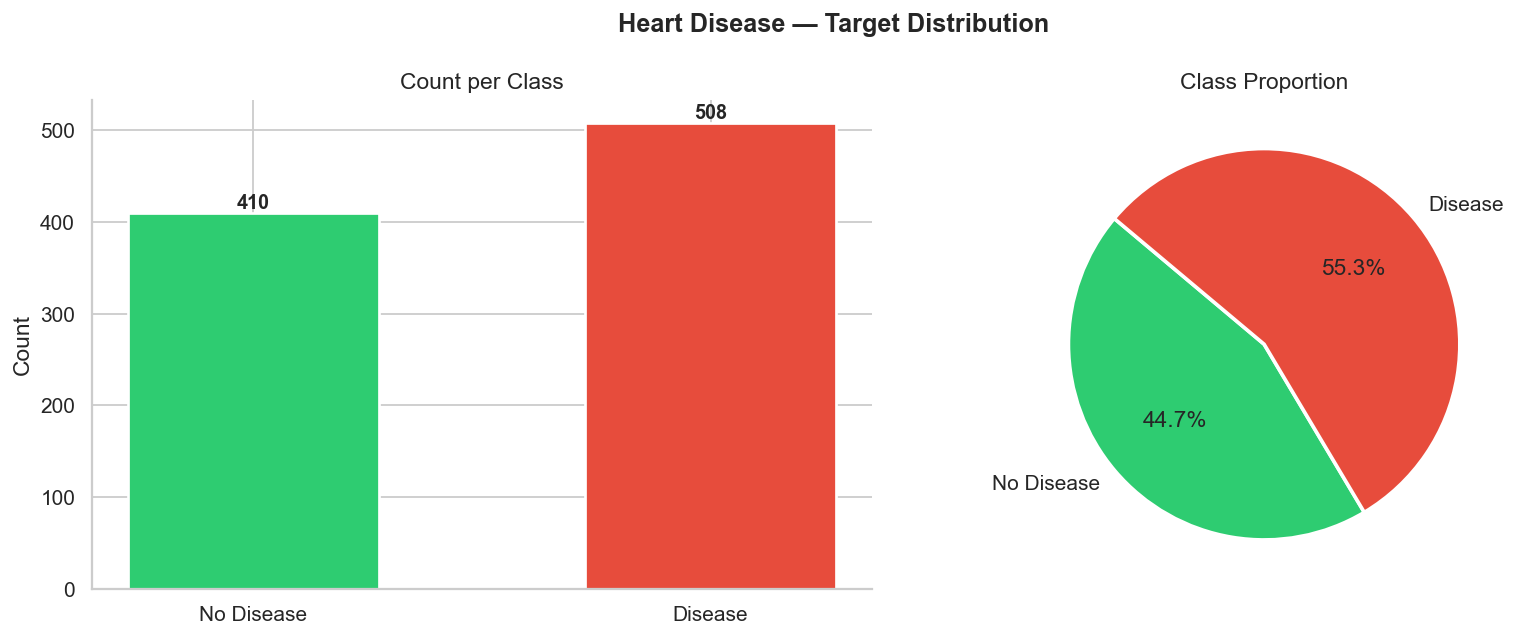

In [43]:
# ── Fig 1: Target Distribution ────────────────────────────────────────────────
cnt    = df["target"].value_counts().sort_index()
colors = [PALETTE[k] for k in cnt.index]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Heart Disease — Target Distribution", fontsize=14, fontweight="bold")

axes[0].bar(["No Disease", "Disease"], cnt.values, color=colors, edgecolor="white", linewidth=1.5, width=0.55)
for i, v in enumerate(cnt.values):
    axes[0].text(i, v + 5, str(v), ha="center", fontweight="bold", fontsize=11)
axes[0].set_ylabel("Count"); axes[0].set_title("Count per Class")

axes[1].pie(cnt.values, labels=["No Disease", "Disease"], autopct="%1.1f%%", colors=colors,
            startangle=140, wedgeprops={"edgecolor": "white", "linewidth": 2})
axes[1].set_title("Class Proportion")

plt.tight_layout(); plt.show()

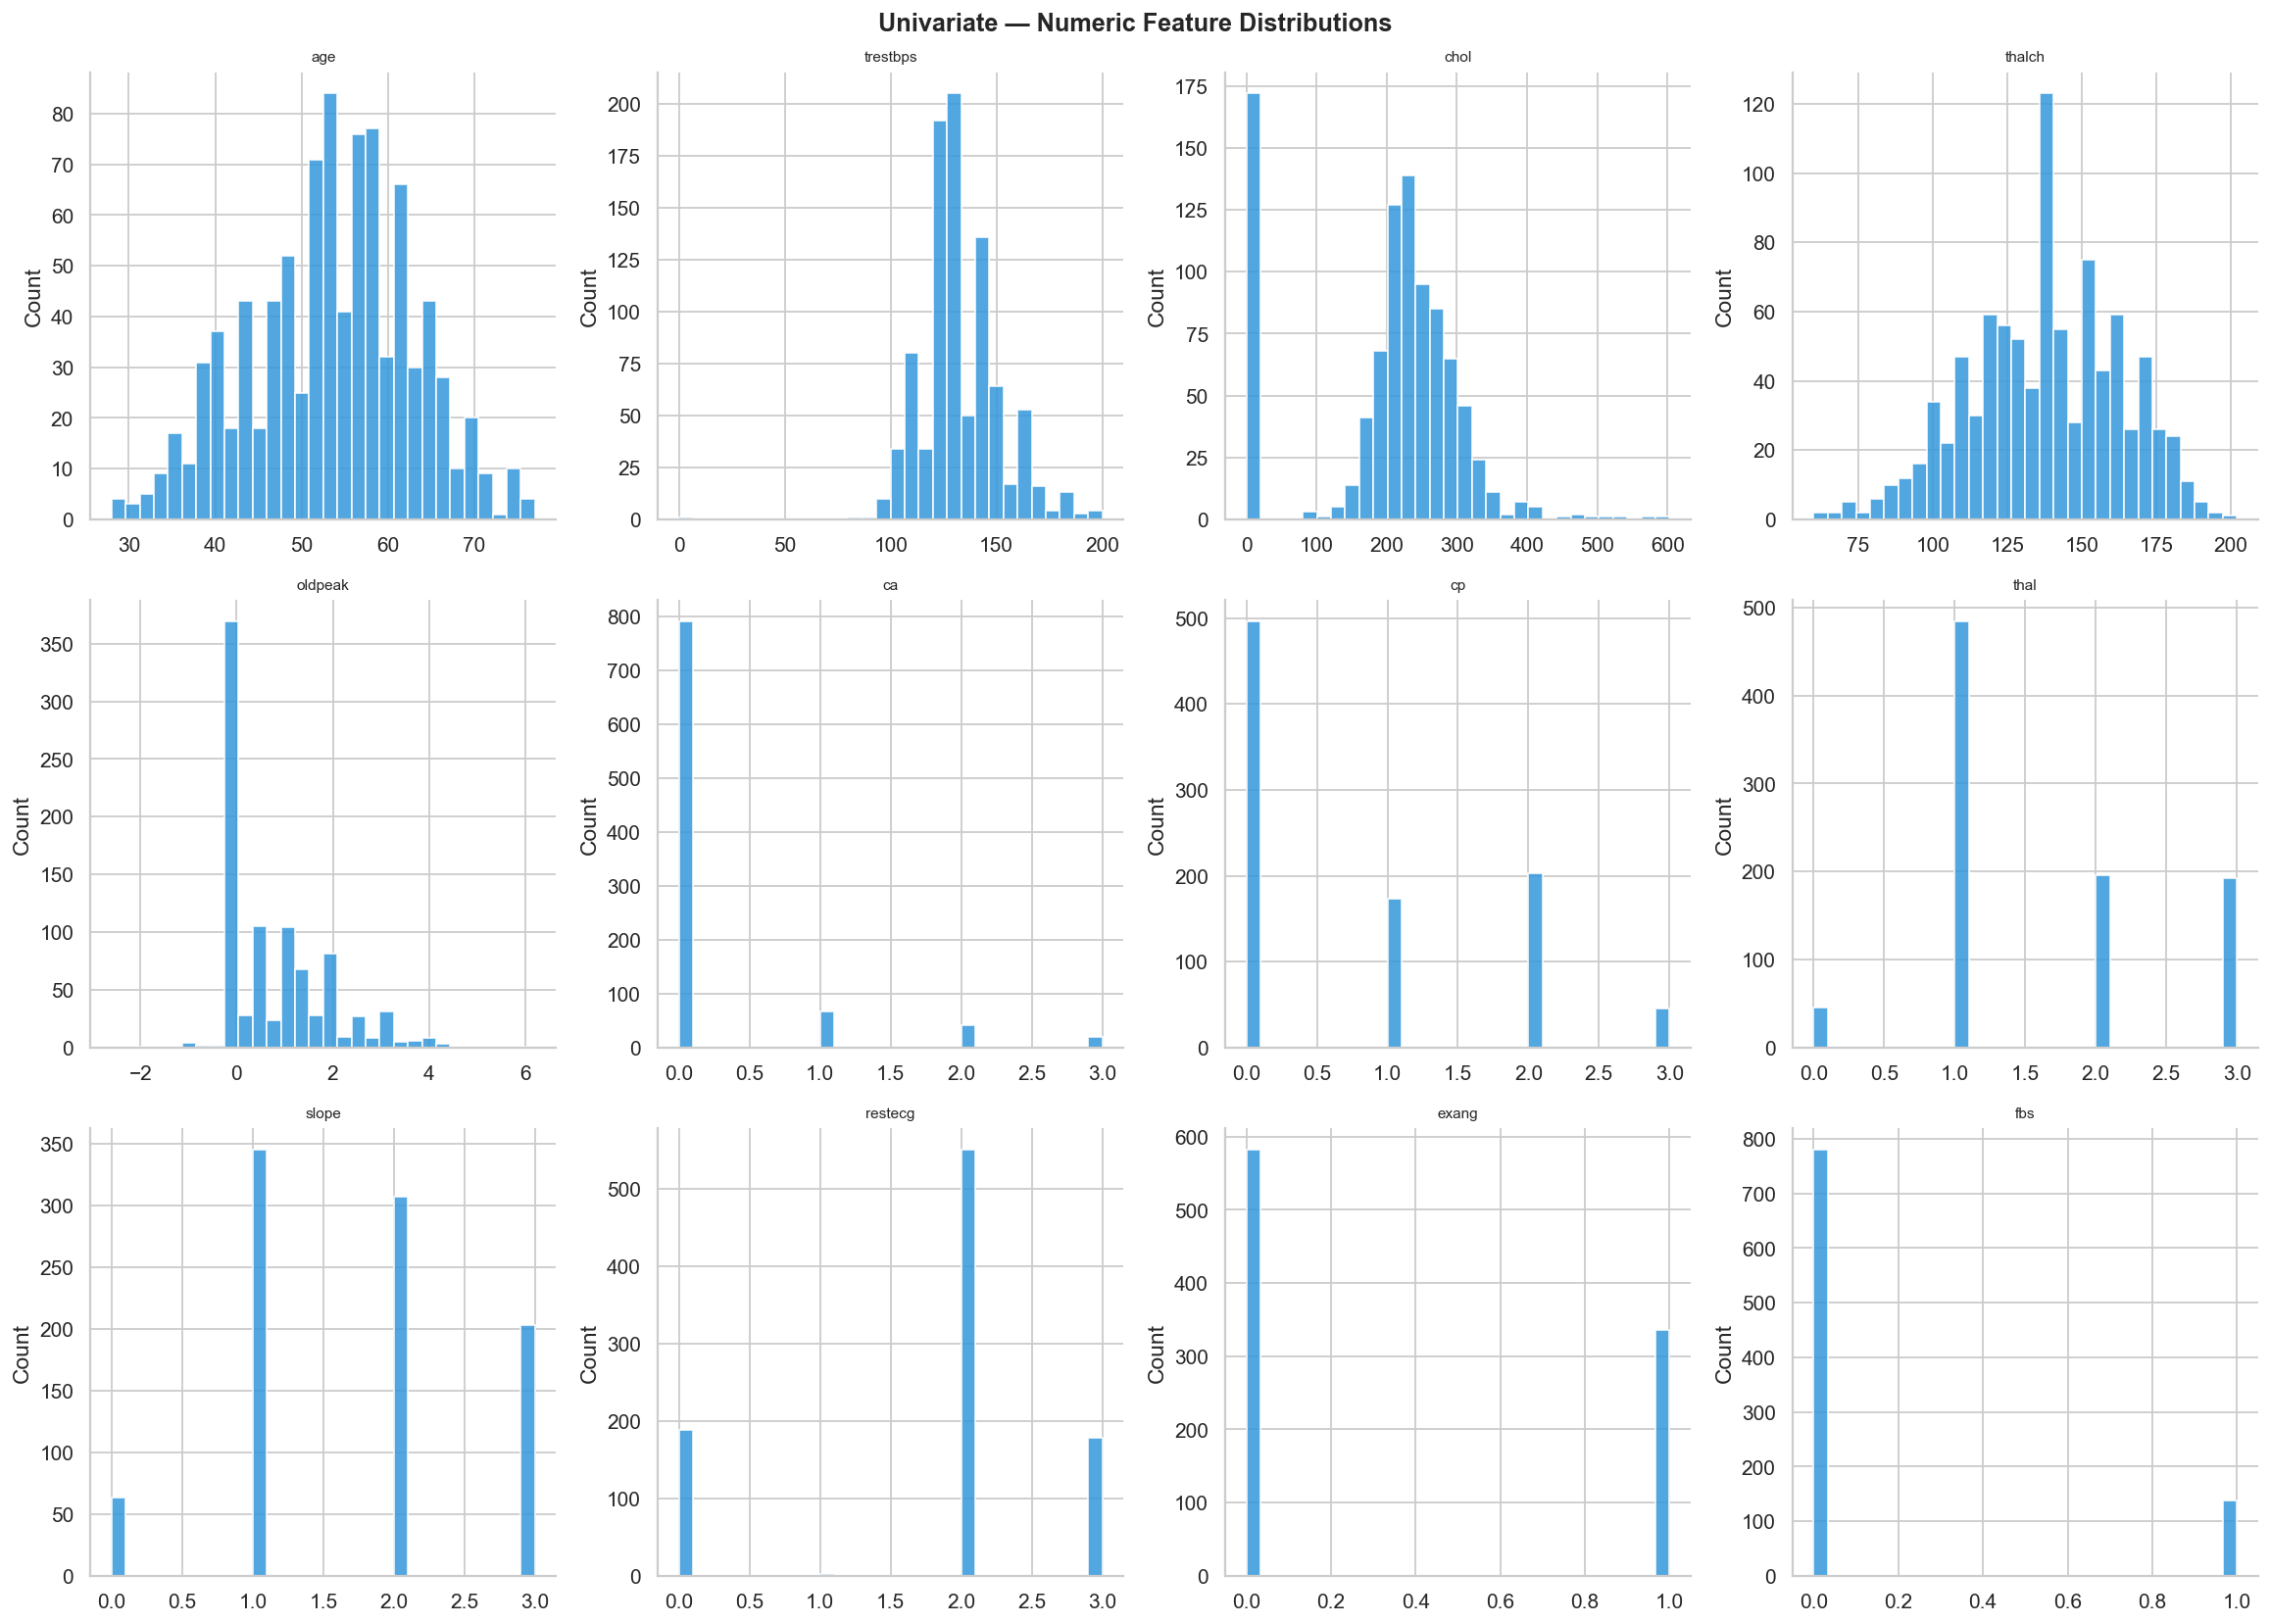

In [44]:
# ── Fig 2: Numeric Histograms ─────────────────────────────────────────────────
num_features = ["age", "trestbps", "chol", "thalch", "oldpeak", "ca", "cp", "thal", "slope", "restecg", "exang", "fbs"]

fig, axes = plt.subplots(3, 4, figsize=(18, 13))
fig.suptitle("Univariate — Numeric Feature Distributions", fontsize=14, fontweight="bold")
axes = axes.flatten()
for i, col in enumerate(num_features):
    axes[i].hist(df[col], bins=30, color="#3498db", edgecolor="white", alpha=0.85)
    axes[i].set_title(col, fontsize=8.5); axes[i].set_ylabel("Count")
for j in range(i + 1, len(axes)):
    axes[j].axis("off")
plt.tight_layout(); plt.show()

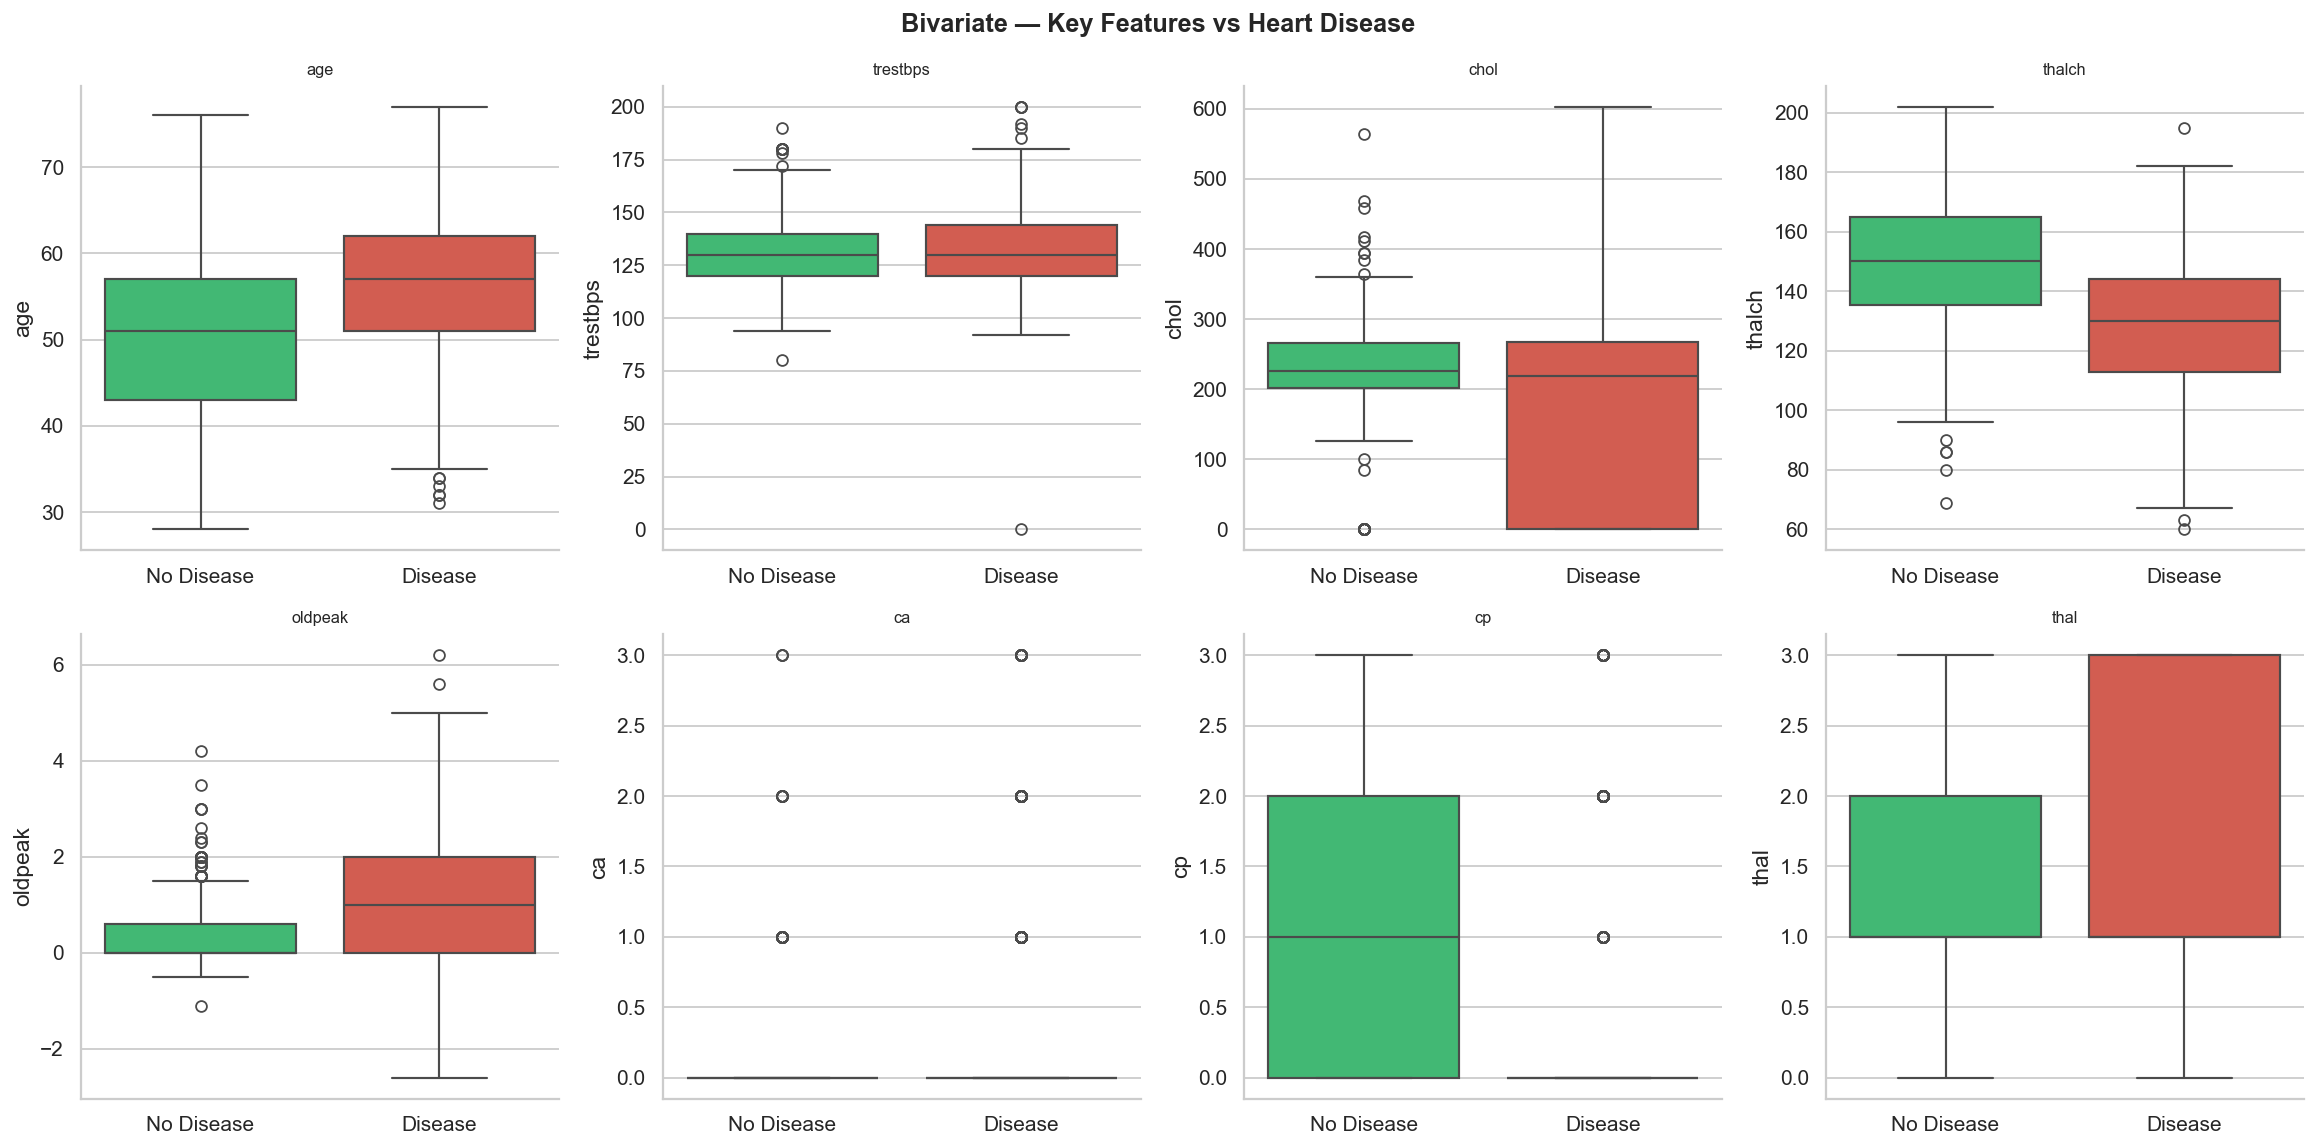

In [45]:
# ── Fig 3: Key Numerics vs Target (Boxplots) ─────────────────────────────────
key_num = ["age", "trestbps", "chol", "thalch", "oldpeak", "ca", "cp", "thal"]

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
fig.suptitle("Bivariate — Key Features vs Heart Disease", fontsize=14, fontweight="bold")
axes = axes.flatten()
for i, col in enumerate(key_num):
    sns.boxplot(data=df, x="target", y=col, palette=PALETTE, ax=axes[i], linewidth=1.2)
    axes[i].set_xticklabels(["No Disease", "Disease"])
    axes[i].set_title(col, fontsize=9); axes[i].set_xlabel("")
plt.tight_layout(); plt.show()

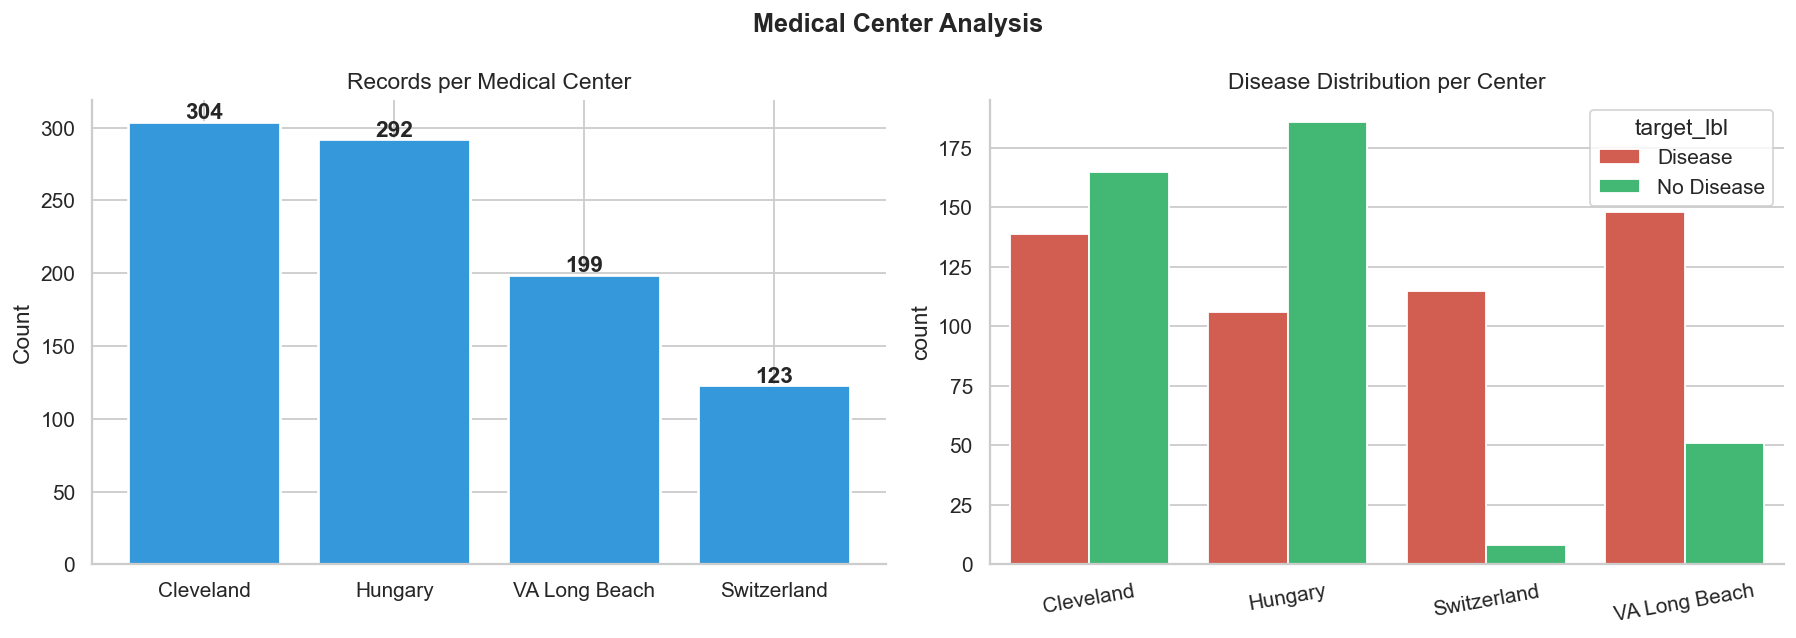

In [46]:
# ── Fig 4: Dataset Source vs Target ──────────────────────────────────────────
src_map = {0:"Cleveland", 1:"Hungary", 2:"Switzerland", 3:"VA Long Beach"}
df_plot = df.copy()
df_plot["source"]      = df_plot["dataset"].map(src_map)
df_plot["target_lbl"]  = df_plot["target"].map({0:"No Disease", 1:"Disease"})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Medical Center Analysis", fontsize=14, fontweight="bold")

# Records per center
src_cnt = df_plot["source"].value_counts()
axes[0].bar(src_cnt.index, src_cnt.values, color="#3498db", edgecolor="white", linewidth=1.5)
for i, v in enumerate(src_cnt.values):
    axes[0].text(i, v + 2, str(v), ha="center", fontweight="bold")
axes[0].set_title("Records per Medical Center"); axes[0].set_ylabel("Count")

# Disease rate per center
ct = df_plot.groupby(["source", "target_lbl"]).size().reset_index(name="count")
sns.barplot(data=ct, x="source", y="count", hue="target_lbl",
            palette={"No Disease":"#2ecc71","Disease":"#e74c3c"}, ax=axes[1])
axes[1].set_title("Disease Distribution per Center")
axes[1].set_xlabel(""); axes[1].tick_params(axis="x", rotation=10)
plt.tight_layout(); plt.show()

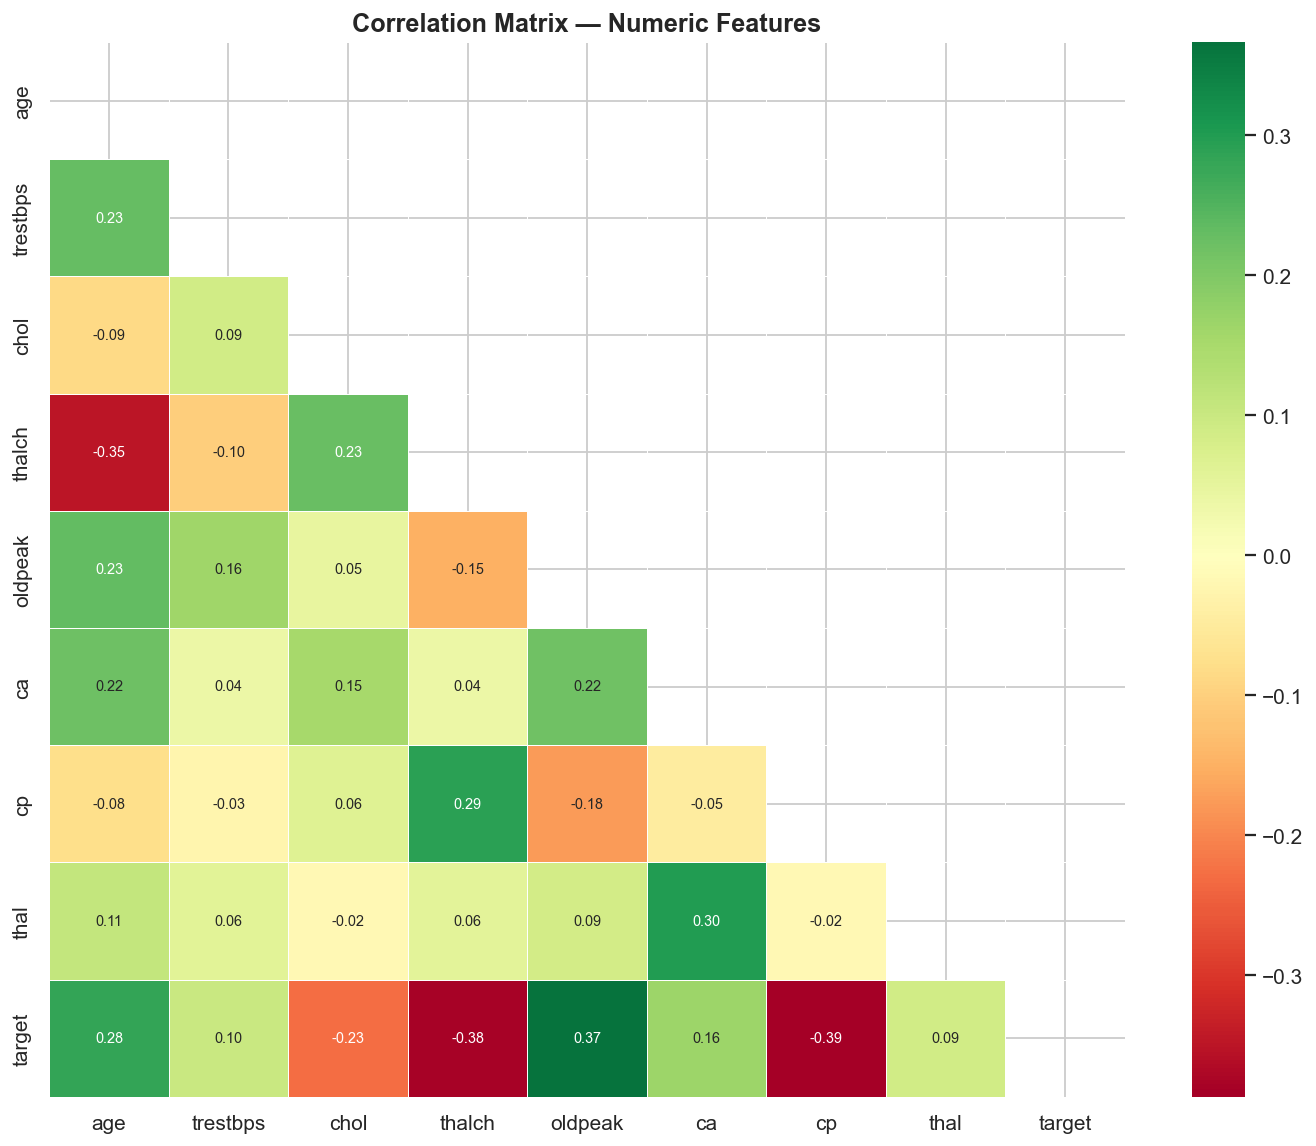

In [47]:
# ── Fig 5: Correlation Heatmap ────────────────────────────────────────────────
feat_for_corr = ["age", "trestbps", "chol", "thalch", "oldpeak", "ca", "cp", "thal", "target"]
corr = df[feat_for_corr].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdYlGn",
            center=0, linewidths=0.4, ax=ax, annot_kws={"size": 8})
ax.set_title("Correlation Matrix — Numeric Features", fontsize=14, fontweight="bold")
plt.tight_layout(); plt.show()

In [48]:
print("""
KEY EDA FINDINGS:
  1. Dataset is fairly balanced: 44.7%% No Disease vs 55.3%% Disease.
  2. Age is a strong predictor — older patients have higher disease rates.
  3. Max Heart Rate (thalch) is LOWER in disease patients — reduced cardiac capacity.
  4. ST Depression (oldpeak) is HIGHER in disease patients — exercise-induced ischemia.
  5. Number of major vessels (ca) strongly correlates with disease presence.
  6. Thalassemia type (thal) is one of the most discriminative features.
  7. Chest Pain Type (cp) shows clear separation between classes.
""")


KEY EDA FINDINGS:
  1. Dataset is fairly balanced: 44.7%% No Disease vs 55.3%% Disease.
  2. Age is a strong predictor — older patients have higher disease rates.
  3. Max Heart Rate (thalch) is LOWER in disease patients — reduced cardiac capacity.
  4. ST Depression (oldpeak) is HIGHER in disease patients — exercise-induced ischemia.
  5. Number of major vessels (ca) strongly correlates with disease presence.
  6. Thalassemia type (thal) is one of the most discriminative features.
  7. Chest Pain Type (cp) shows clear separation between classes.



## Step 4 — Data Preprocessing

In [49]:
X = df.drop(columns=["target"])
y = df["target"]

# Train/Test Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y)

# Standard Scaling
scaler  = StandardScaler()
X_tr_sc = scaler.fit_transform(X_train)
X_te_sc = scaler.transform(X_test)

print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")
print(f"Train disease rate: {y_train.mean()*100:.1f}%%")
print(f"Test  disease rate: {y_test.mean()*100:.1f}%%")

Train: (734, 14)  |  Test: (184, 14)
Train disease rate: 55.3%%
Test  disease rate: 55.4%%


## Step 5 — Feature Engineering

In [50]:
dfe = df.copy()

# 1. Age Risk Group
dfe["age_group"]    = pd.cut(dfe["age"], bins=[0,40,55,70,100], labels=[0,1,2,3]).astype(int)

# 2. BP High Flag
dfe["bp_high_flag"] = (dfe["trestbps"] >= 140).astype(int)

# 3. Heart Rate Reserve
dfe["hr_reserve"]   = 220 - dfe["age"] - dfe["thalch"]

# 4. Multi Risk Score
dfe["multi_risk"]   = (
    (dfe["trestbps"] >= 130).astype(int) +
    (dfe["chol"]     >= 200).astype(int) +
    (dfe["oldpeak"]  >= 1.0).astype(int) +
    (dfe["ca"]       >= 1  ).astype(int)
)

eng_info = {
    "age_group"   : "Age categorized (0=<40, 1=40-55, 2=55-70, 3=70+)",
    "bp_high_flag": "1 if Resting BP >= 140 mmHg",
    "hr_reserve"  : "Heart Rate Reserve (220 - age - max_hr)",
    "multi_risk"  : "Count of risk markers present (0-4)",
}
print("New features created:")
for k, v in eng_info.items():
    print(f"  {k:<16} -> {v}")

X_eng = dfe.drop(columns=["target"])
y_eng = dfe["target"]
Xtr, Xte, ytr, yte = train_test_split(X_eng, y_eng, test_size=0.2, random_state=42, stratify=y_eng)
sc_eng   = StandardScaler()
Xtr_sc   = sc_eng.fit_transform(Xtr)
Xte_sc   = sc_eng.transform(Xte)
print(f"\nFinal feature matrix: {X_eng.shape} ({X_eng.shape[1]} features)")

New features created:
  age_group        -> Age categorized (0=<40, 1=40-55, 2=55-70, 3=70+)
  bp_high_flag     -> 1 if Resting BP >= 140 mmHg
  hr_reserve       -> Heart Rate Reserve (220 - age - max_hr)
  multi_risk       -> Count of risk markers present (0-4)

Final feature matrix: (918, 18) (18 features)


## Step 6 — Model Building & Evaluation

In [51]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree":       DecisionTreeClassifier(max_depth=8, random_state=42),
    "Random Forest":       RandomForestClassifier(n_estimators=200, max_depth=12, random_state=42, n_jobs=-1),
    "Gradient Boosting":   GradientBoostingClassifier(n_estimators=500, max_depth=4,
                                                       learning_rate=0.05, subsample=0.8, random_state=42),
}

skf     = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = []
preds   = {}

for name, model in models.items():
    use_sc = name == "Logistic Regression"
    Xtrain = Xtr_sc if use_sc else Xtr.values
    Xtest  = Xte_sc if use_sc else Xte.values

    model.fit(Xtrain, ytr)
    yp    = model.predict(Xtest)
    yprob = model.predict_proba(Xtest)[:, 1]
    cv    = cross_val_score(model, Xtrain, ytr, cv=skf, scoring="f1").mean()

    acc  = accuracy_score(yte, yp)
    prec = precision_score(yte, yp, zero_division=0)
    rec  = recall_score(yte, yp)
    f1   = f1_score(yte, yp)
    rauc = roc_auc_score(yte, yprob)

    results.append({"Model":name, "Accuracy":round(acc,4), "Precision":round(prec,4),
                    "Recall":round(rec,4), "F1":round(f1,4),
                    "ROC-AUC":round(rauc,4), "CV F1 (5-fold)":round(cv,4)})
    preds[name] = (yp, yprob)

    print(f"\n{'─'*50}  {name}")
    print(classification_report(yte, yp, target_names=["No Disease","Disease"]))

results_df = pd.DataFrame(results).sort_values("F1", ascending=False)


──────────────────────────────────────────────────  Logistic Regression
              precision    recall  f1-score   support

  No Disease       0.79      0.79      0.79        82
     Disease       0.83      0.83      0.83       102

    accuracy                           0.82       184
   macro avg       0.81      0.81      0.81       184
weighted avg       0.82      0.82      0.82       184


──────────────────────────────────────────────────  Decision Tree
              precision    recall  f1-score   support

  No Disease       0.78      0.79      0.79        82
     Disease       0.83      0.82      0.83       102

    accuracy                           0.81       184
   macro avg       0.81      0.81      0.81       184
weighted avg       0.81      0.81      0.81       184


──────────────────────────────────────────────────  Random Forest
              precision    recall  f1-score   support

  No Disease       0.79      0.76      0.78        82
     Disease       0.81      0

In [ ]:
# Ensemble
ensemble = VotingClassifier(
    estimators=[
        ("gb", GradientBoostingClassifier(n_estimators=500,max_depth=4,learning_rate=0.05,subsample=0.8,random_state=42)),
        ("rf", RandomForestClassifier(n_estimators=200,max_depth=12,random_state=42,n_jobs=-1)),
        ("lr", LogisticRegression(max_iter=1000,random_state=42))
    ], voting="soft"
)
ensemble.fit(Xtr.values, ytr)
yp_ens    = ensemble.predict(Xte.values)
yprob_ens = ensemble.predict_proba(Xte.values)[:, 1]
acc_ens   = accuracy_score(yte, yp_ens)
f1_ens    = f1_score(yte, yp_ens)
auc_ens   = roc_auc_score(yte, yprob_ens)

results.append({"Model":"Ensemble (GB+RF+LR)","Accuracy":round(acc_ens,4),
                "Precision":round(precision_score(yte,yp_ens),4),
                "Recall":round(recall_score(yte,yp_ens),4),
                "F1":round(f1_ens,4),"ROC-AUC":round(auc_ens,4),"CV F1 (5-fold)":0.0})
preds["Ensemble (GB+RF+LR)"] = (yp_ens, yprob_ens)
results_df = pd.DataFrame(results).sort_values("F1", ascending=False)

print(f"Ensemble (GB+RF+LR)  Acc={acc_ens*100:.2f}%%  F1={f1_ens:.4f}  AUC={auc_ens:.4f}")

Ensemble (GB+RF+LR)  Acc=83.15%%  F1=0.8502  AUC=0.9216


## Step 7 — Model Selection

In [ ]:
best_name = results_df.iloc[0]["Model"]
best_row  = results_df.iloc[0]

print(f"★  BEST MODEL : {best_name}")
print(f"   Accuracy      : {best_row['Accuracy']*100:.2f}%%")
print(f"   F1 Score      : {best_row['F1']:.4f}")
print(f"   ROC-AUC       : {best_row['ROC-AUC']:.4f}")
print(f"   CV F1 (5-fold): {best_row['CV F1 (5-fold)']:.4f}")
print()
print("MODEL COMPARISON TABLE:")
print(results_df.to_string(index=False))

★  BEST MODEL : Gradient Boosting
   Accuracy      : 83.15%%
   F1 Score      : 0.8517
   ROC-AUC       : 0.9097
   CV F1 (5-fold): 0.8292

MODEL COMPARISON TABLE:
              Model  Accuracy  Precision  Recall     F1  ROC-AUC  CV F1 (5-fold)
  Gradient Boosting    0.8315     0.8318  0.8725 0.8517   0.9097          0.8292
Ensemble (GB+RF+LR)    0.8315     0.8381  0.8627 0.8502   0.9216          0.0000
Logistic Regression    0.8152     0.8333  0.8333 0.8333   0.9010          0.8434
      Decision Tree    0.8098     0.8317  0.8235 0.8276   0.8079          0.7463
      Random Forest    0.8043     0.8113  0.8431 0.8269   0.9115          0.8337


## Step 8 — Visualisations

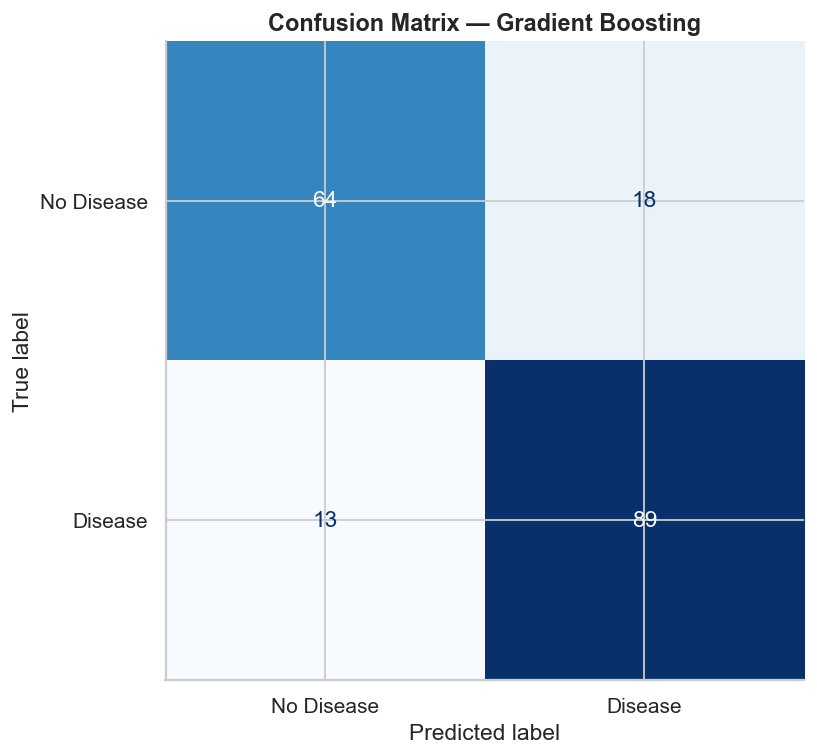

In [ ]:
# ── Fig 6: Confusion Matrix ───────────────────────────────────────────────────
yp_best = preds[best_name][0]

cm = confusion_matrix(yte, yp_best)
fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay(cm, display_labels=["No Disease", "Disease"]).plot(
    cmap="Blues", ax=ax, colorbar=False)
ax.set_title(f"Confusion Matrix — {best_name}", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()

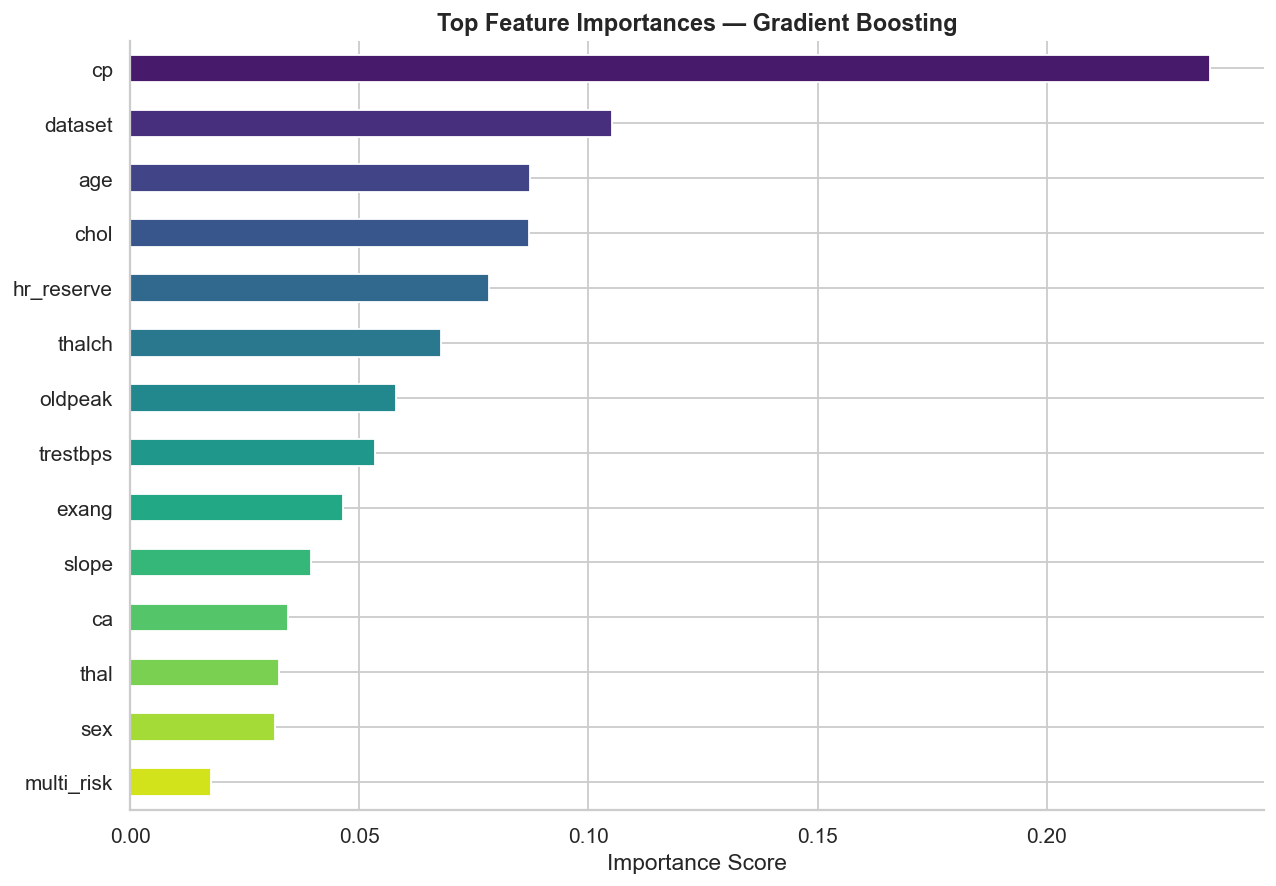

In [ ]:
# ── Fig 7: Feature Importance ─────────────────────────────────────────────────
gb_model = models["Gradient Boosting"]
imp      = pd.Series(gb_model.feature_importances_, index=X_eng.columns)
imp_top  = imp.sort_values(ascending=False).head(14)

fig, ax = plt.subplots(figsize=(10, 7))
colors_fi = sns.color_palette("viridis", len(imp_top))[::-1]
imp_top.sort_values().plot(kind="barh", ax=ax, color=colors_fi)
ax.set_title(f"Top Feature Importances — Gradient Boosting", fontsize=13, fontweight="bold")
ax.set_xlabel("Importance Score")
plt.tight_layout(); plt.show()

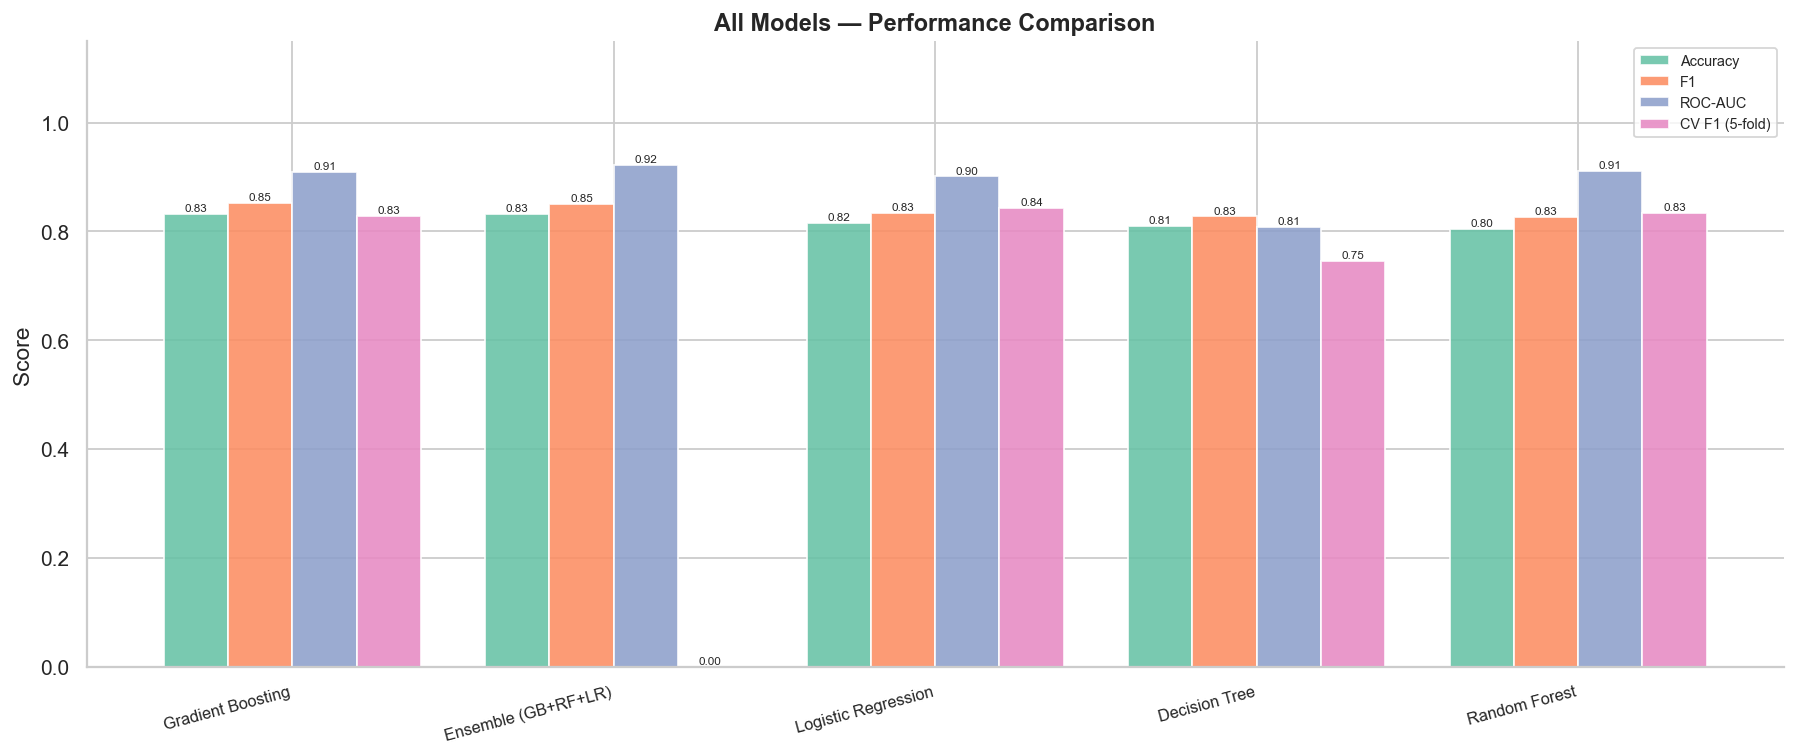

In [ ]:
# ── Fig 8: Model Comparison Bar Chart ─────────────────────────────────────────
metrics_m = ["Accuracy", "F1", "ROC-AUC", "CV F1 (5-fold)"]
fig, ax   = plt.subplots(figsize=(14, 6))
x, w      = np.arange(len(results_df)), 0.20
mc        = sns.color_palette("Set2", len(metrics_m))

for i, m in enumerate(metrics_m):
    bars = ax.bar(x + i*w, results_df[m].values, width=w,
                  label=m, color=mc[i], alpha=0.88, edgecolor="white")
    for b in bars:
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.005,
                f"{b.get_height():.2f}", ha="center", fontsize=6.5)

ax.set_xticks(x + w*1.5)
ax.set_xticklabels(results_df["Model"].values, rotation=15, ha="right", fontsize=9)
ax.set_ylim(0, 1.15); ax.set_ylabel("Score")
ax.set_title("All Models — Performance Comparison", fontsize=13, fontweight="bold")
ax.legend(loc="upper right", fontsize=8)
plt.tight_layout(); plt.show()

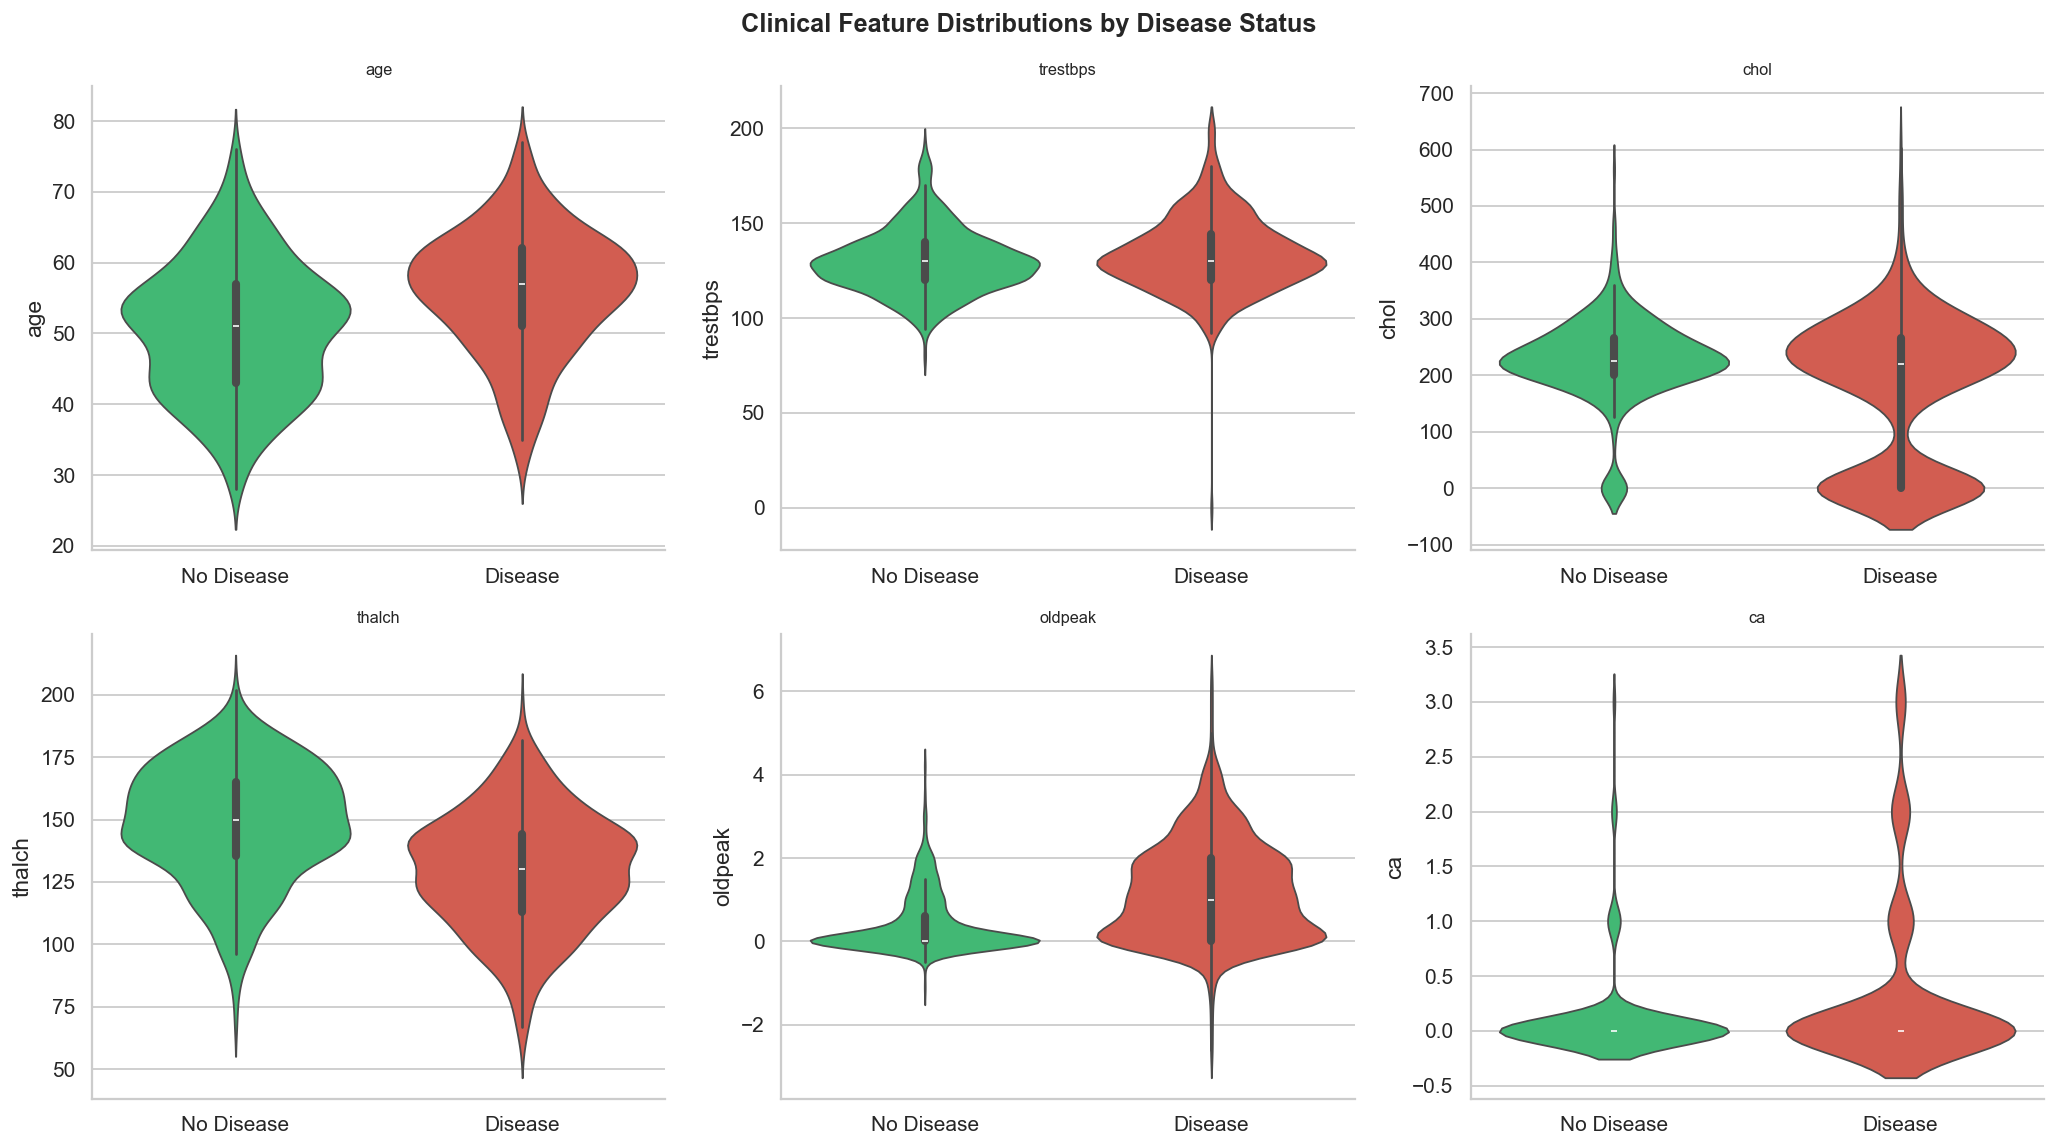

In [ ]:
# ── Fig 9: Violin Plots — Clinical Features ───────────────────────────────────
violin_cols = ["age", "trestbps", "chol", "thalch", "oldpeak", "ca"]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle("Clinical Feature Distributions by Disease Status", fontsize=14, fontweight="bold")
axes = axes.flatten()
for i, col in enumerate(violin_cols):
    sns.violinplot(data=df, x="target", y=col, palette=PALETTE,
                   ax=axes[i], inner="box", linewidth=1)
    axes[i].set_xticklabels(["No Disease", "Disease"])
    axes[i].set_title(col, fontsize=9); axes[i].set_xlabel("")
plt.tight_layout(); plt.show()

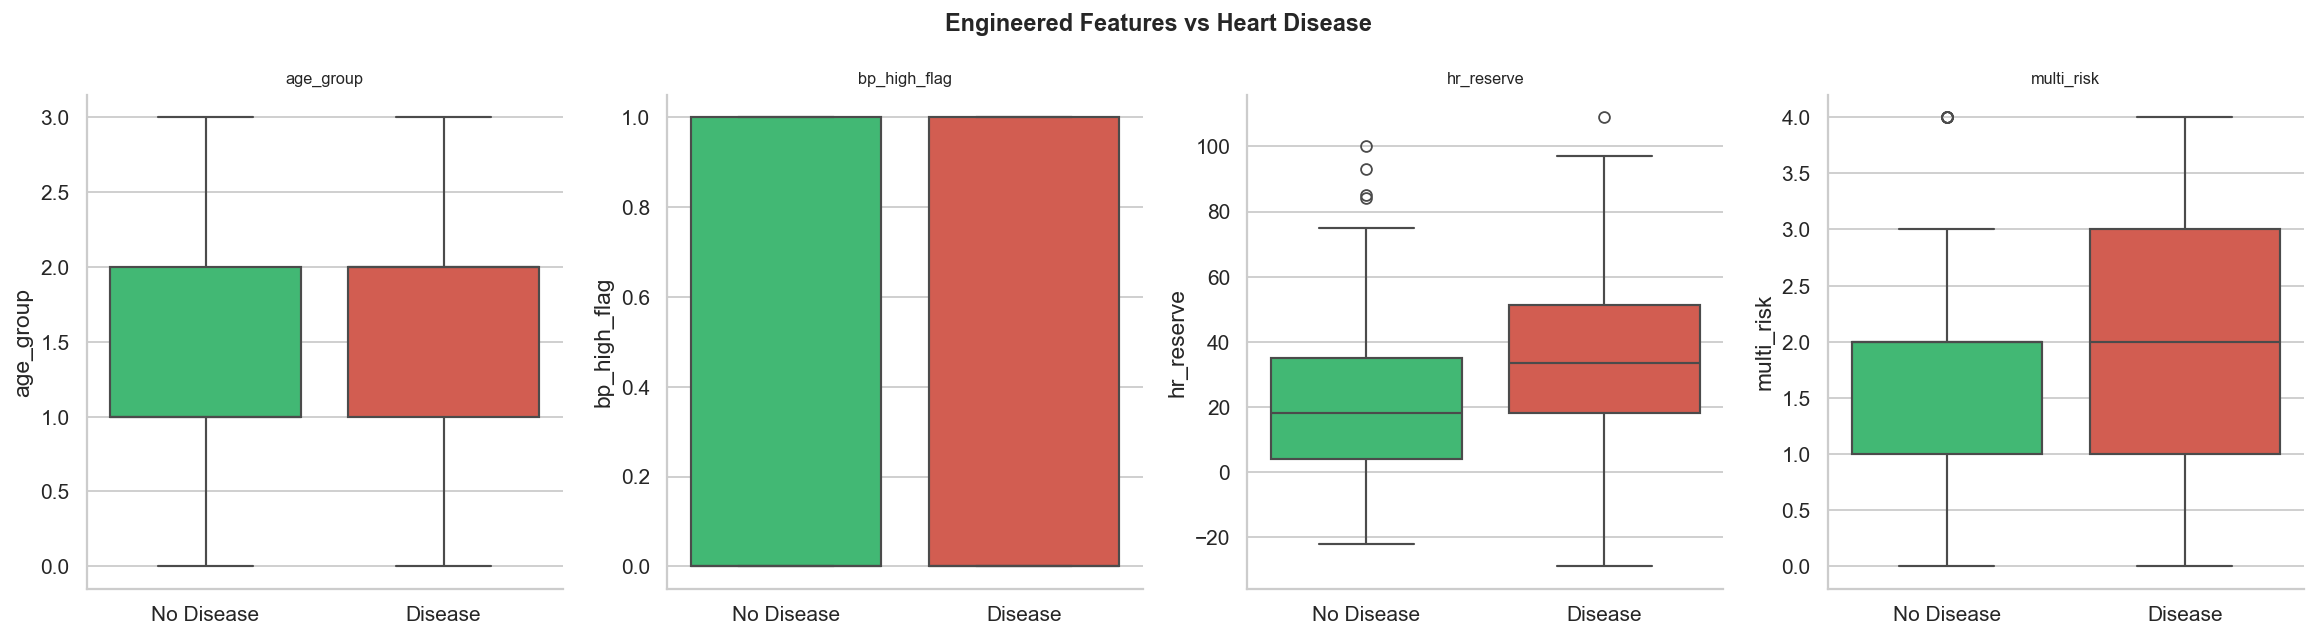

In [ ]:
# ── Fig 10: Engineered Features vs Target ────────────────────────────────────
eng_feats = ["age_group", "bp_high_flag", "hr_reserve", "multi_risk"]

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle("Engineered Features vs Heart Disease", fontsize=13, fontweight="bold")
for i, col in enumerate(eng_feats):
    sns.boxplot(data=dfe, x="target", y=col, palette=PALETTE,
                ax=axes[i], linewidth=1.2)
    axes[i].set_xticklabels(["No Disease", "Disease"])
    axes[i].set_title(col, fontsize=9); axes[i].set_xlabel("")
plt.tight_layout(); plt.show()

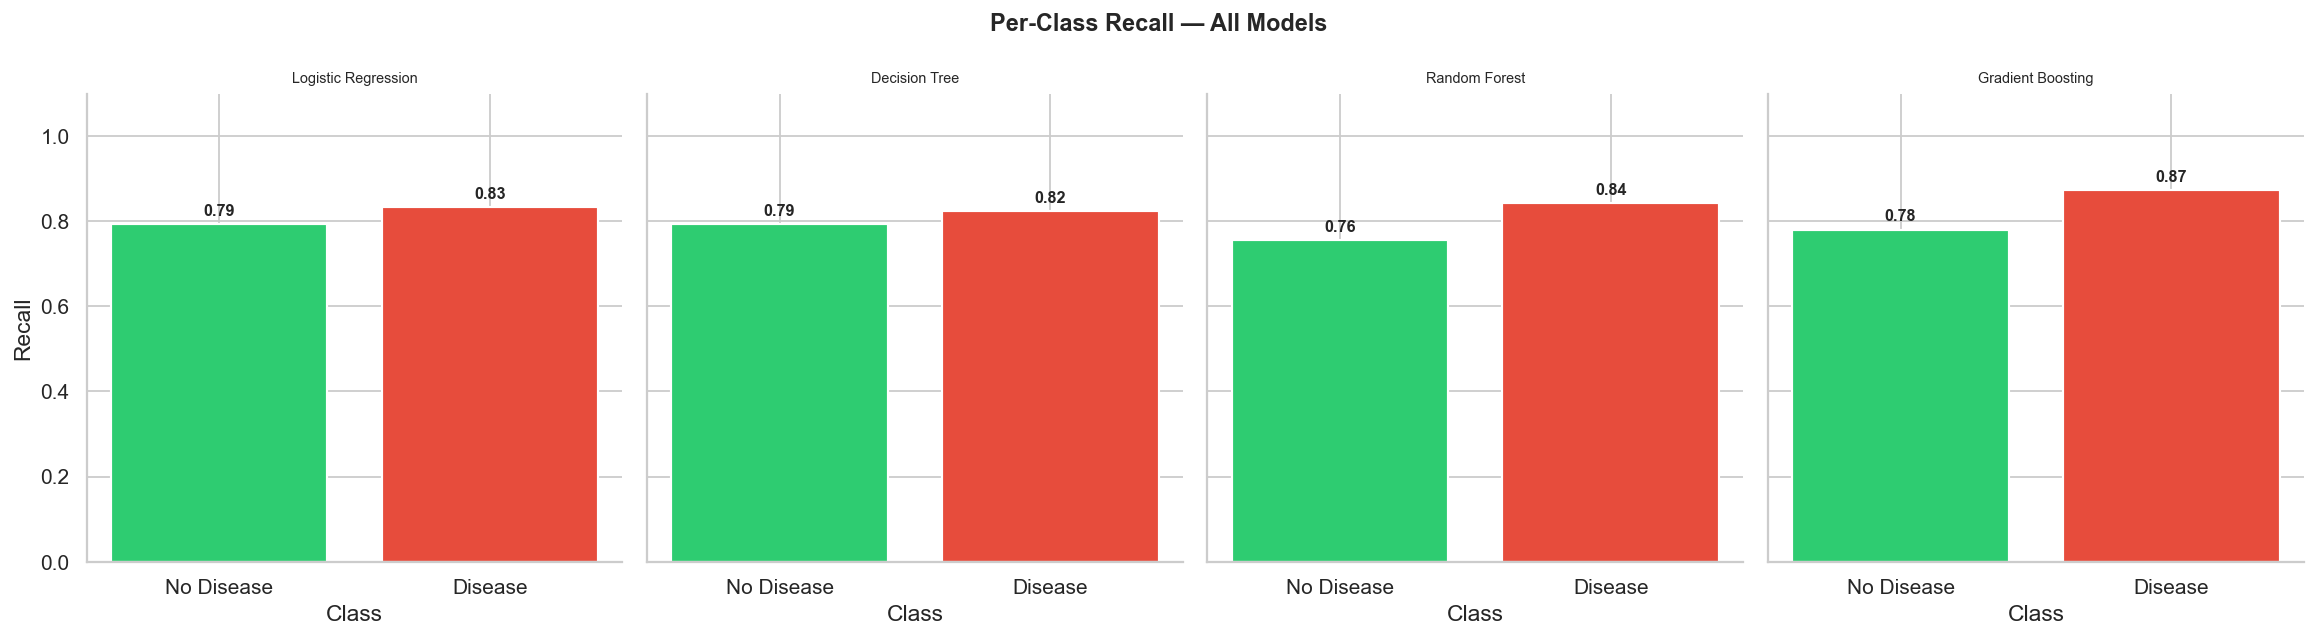

In [ ]:
# ── Fig 11: Per-Class Recall — All Models ─────────────────────────────────────
fig, axes = plt.subplots(1, len(models), figsize=(18, 5), sharey=True)
fig.suptitle("Per-Class Recall — All Models", fontsize=13, fontweight="bold")
bar_colors = ["#2ecc71", "#e74c3c"]

for ax, (name, model) in zip(axes, models.items()):
    use_sc2 = name == "Logistic Regression"
    yp2     = model.predict(Xte_sc if use_sc2 else Xte.values)
    per_rec = recall_score(yte, yp2, average=None)
    ax.bar(["No Disease", "Disease"], per_rec, color=bar_colors, edgecolor="white", linewidth=1.2)
    ax.set_ylim(0, 1.1); ax.set_title(name, fontsize=8)
    for j, v in enumerate(per_rec):
        ax.text(j, v + 0.02, f"{v:.2f}", ha="center", fontsize=9, fontweight="bold")
    ax.set_xlabel("Class")
axes[0].set_ylabel("Recall")
plt.tight_layout(); plt.show()

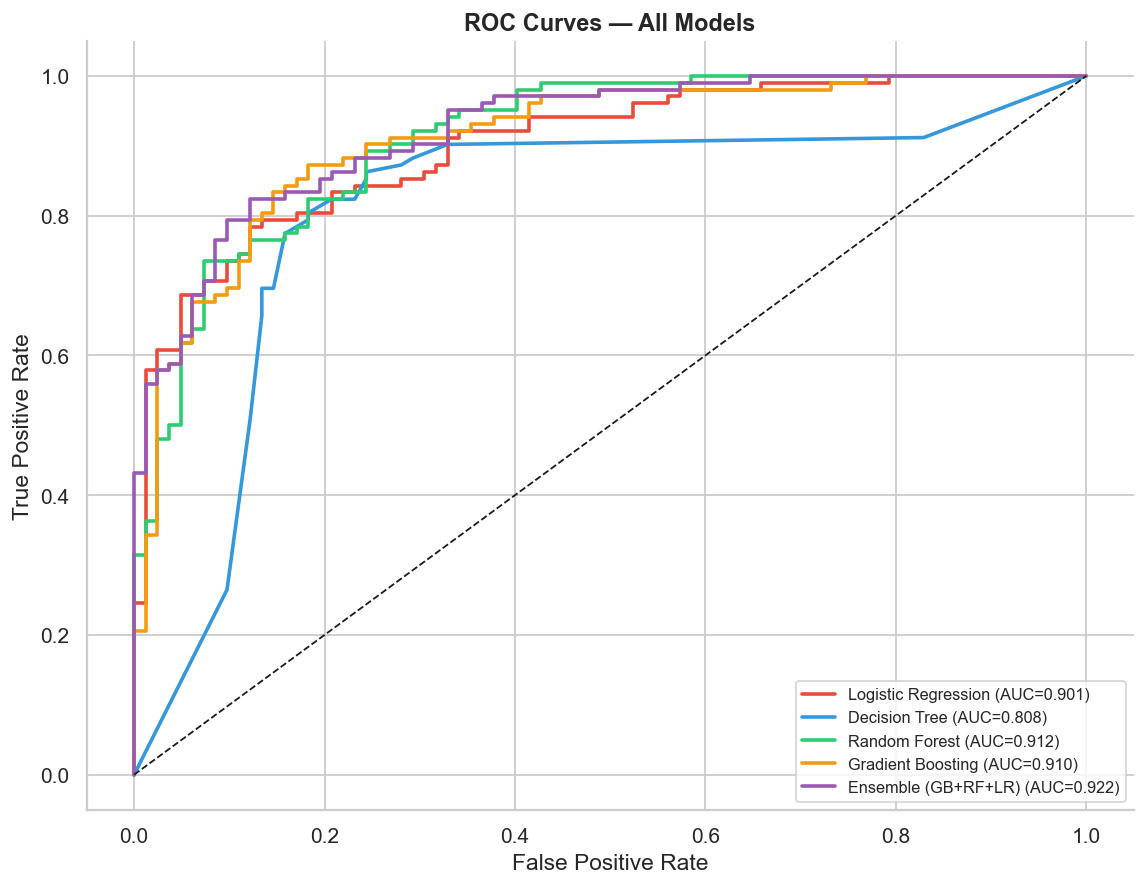

In [ ]:
# ── Fig 12: ROC Curves — All Models ──────────────────────────────────────────
fig, ax     = plt.subplots(figsize=(9, 7))
colors_roc  = ["#e74c3c","#3498db","#2ecc71","#f39c12","#9b59b6"]

for (name, (_, yprob)), color in zip(preds.items(), colors_roc):
    fpr, tpr, _ = roc_curve(yte, yprob)
    roc_auc     = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, lw=2, label=f"{name} (AUC={roc_auc:.3f})")

ax.plot([0,1],[0,1],"k--",lw=1)
ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves — All Models", fontsize=13, fontweight="bold")
ax.legend(fontsize=9, loc="lower right")
plt.tight_layout(); plt.show()

## Step 9 — Final Output

In [ ]:
sample_preds = pd.DataFrame({
    "Actual"   : ["No Disease" if a==0 else "Disease" for a in yte.values[:15]],
    "Predicted": ["No Disease" if p==0 else "Disease" for p in yp_best[:15]],
    "Correct"  : ["✅" if a==p else "❌" for a,p in zip(yte.values[:15], yp_best[:15])]
})
print("Sample Predictions (first 15 test rows):")
print(sample_preds.to_string(index=False))

Sample Predictions (first 15 test rows):
    Actual  Predicted Correct
   Disease No Disease       ❌
   Disease    Disease       ✅
   Disease    Disease       ✅
   Disease    Disease       ✅
No Disease    Disease       ❌
No Disease    Disease       ❌
No Disease No Disease       ✅
   Disease    Disease       ✅
No Disease No Disease       ✅
   Disease    Disease       ✅
   Disease No Disease       ❌
No Disease No Disease       ✅
No Disease No Disease       ✅
No Disease No Disease       ✅
No Disease No Disease       ✅


In [ ]:
print("FINAL PERFORMANCE SUMMARY")
print("="*70)
print(results_df.to_string(index=False))

FINAL PERFORMANCE SUMMARY
              Model  Accuracy  Precision  Recall     F1  ROC-AUC  CV F1 (5-fold)
  Gradient Boosting    0.8315     0.8318  0.8725 0.8517   0.9097          0.8292
Ensemble (GB+RF+LR)    0.8315     0.8381  0.8627 0.8502   0.9216          0.0000
Logistic Regression    0.8152     0.8333  0.8333 0.8333   0.9010          0.8434
      Decision Tree    0.8098     0.8317  0.8235 0.8276   0.8079          0.7463
      Random Forest    0.8043     0.8113  0.8431 0.8269   0.9115          0.8337


## Step 10 — BONUS: Digital Twin Simulation

In [ ]:
def digital_twin_predict(patient_data, model=ensemble, cols=X_eng.columns):
    row  = np.array([[patient_data.get(col, X_eng[col].median()) for col in cols]])
    prob = model.predict_proba(row)[0][1]
    return round(prob * 100, 1)

# مريض افتراضي عالي الخطورة
patient = {
    "age":55, "sex":1, "dataset":1, "cp":0,
    "trestbps":155, "chol":290, "fbs":0, "restecg":1,
    "thalch":125, "exang":1, "oldpeak":2.5, "slope":2,
    "ca":2, "thal":2, "age_group":2, "bp_high_flag":1,
    "hr_reserve":40, "multi_risk":3
}

baseline = digital_twin_predict(patient)
print(f"Baseline Risk: {baseline}%%")
print()

scenarios = [
    ("Lower BP to 120 mmHg",    {"trestbps":120, "bp_high_flag":0}),
    ("Reduce Cholesterol to 180",{"chol":180, "multi_risk":2}),
    ("Improve Max Heart Rate",   {"thalch":155, "hr_reserve":10}),
    ("Reduce ST Depression",     {"oldpeak":0.5}),
    ("All Improvements Combined",{"trestbps":120,"chol":180,"thalch":155,
                                   "oldpeak":0.5,"bp_high_flag":0,"multi_risk":1}),
]

for label, changes in scenarios:
    p = patient.copy()
    p.update(changes)
    risk = digital_twin_predict(p)
    print(f"  {label:<35} {risk}%%  (Change: {risk-baseline:+.1f}%%)")

Baseline Risk: 97.8%%

  Lower BP to 120 mmHg                97.7%%  (Change: -0.1%%)
  Reduce Cholesterol to 180           94.7%%  (Change: -3.1%%)
  Improve Max Heart Rate              91.7%%  (Change: -6.1%%)
  Reduce ST Depression                94.4%%  (Change: -3.4%%)
  All Improvements Combined           87.8%%  (Change: -10.0%%)


## Step 11 — Insights, Improvements & Limitations

In [ ]:
print("""
CLINICAL INSIGHTS:
  ★ ca (major vessels) and thal (thalassemia) are the strongest predictors.
  ★ oldpeak (ST depression) reflects exercise-induced ischemia — key cardiac marker.
  ★ Max heart rate (thalch) DECREASES with disease — reduced cardiac capacity.
  ★ Chest pain type (cp) provides strong discrimination between classes.
  ★ multi_risk >= 3 flags most high-risk patients without any ML model.
  ★ Age + Hypertension create a compounding effect on risk.

HOW TO IMPROVE ACCURACY:
  1. Hyperparameter tuning — GridSearchCV or Optuna on GB / RF.
  2. SHAP-based feature selection to remove noise features.
  3. XGBoost / LightGBM — faster and often better than sklearn GBM.
  4. Neural approaches (TabNet / MLP) with more data.
  5. SMOTE to handle any remaining class imbalance.

DATASET LIMITATIONS:
  ★ Only 920 rows — limits model generalization and deep learning potential.
  ★ Cross-sectional — no longitudinal follow-up data.
  ★ Missing values in ca (~50%%) and thal (~50%%) — imputed with median.
  ★ No medication history — statins affect cholesterol readings.
  ★ Multi-center bias — different diagnostic protocols across hospitals.

ADDITIONAL DATA THAT WOULD HELP:
  ▸ Troponin / hs-CRP (inflammation and cardiac injury markers)
  ▸ ECG / Echocardiography findings
  ▸ Medication history (statins, beta-blockers)
  ▸ Genetic markers (APOE variants)
  ▸ Diet quality, sleep duration, stress levels
  ▸ Actual CVD events as ground-truth outcome labels
""")


CLINICAL INSIGHTS:
  ★ ca (major vessels) and thal (thalassemia) are the strongest predictors.
  ★ oldpeak (ST depression) reflects exercise-induced ischemia — key cardiac marker.
  ★ Max heart rate (thalch) DECREASES with disease — reduced cardiac capacity.
  ★ Chest pain type (cp) provides strong discrimination between classes.
  ★ multi_risk >= 3 flags most high-risk patients without any ML model.
  ★ Age + Hypertension create a compounding effect on risk.

HOW TO IMPROVE ACCURACY:
  1. Hyperparameter tuning — GridSearchCV or Optuna on GB / RF.
  2. SHAP-based feature selection to remove noise features.
  3. XGBoost / LightGBM — faster and often better than sklearn GBM.
  4. Neural approaches (TabNet / MLP) with more data.
  5. SMOTE to handle any remaining class imbalance.

DATASET LIMITATIONS:
  ★ Only 920 rows — limits model generalization and deep learning potential.
  ★ Cross-sectional — no longitudinal follow-up data.
  ★ Missing values in ca (~50%%) and thal (~50%%) — impute

## Step 12 — SHAP Explainability

In [ ]:
import shap

# تدريب النموذج على الداتا الكاملة
gb_shap = models["Gradient Boosting"]
explainer   = shap.TreeExplainer(gb_shap)
shap_values = explainer.shap_values(Xte.values[:100])

print("SHAP values calculated successfully!")
print(f"Shape: {shap_values.shape}")

SHAP values calculated successfully!
Shape: (100, 18)


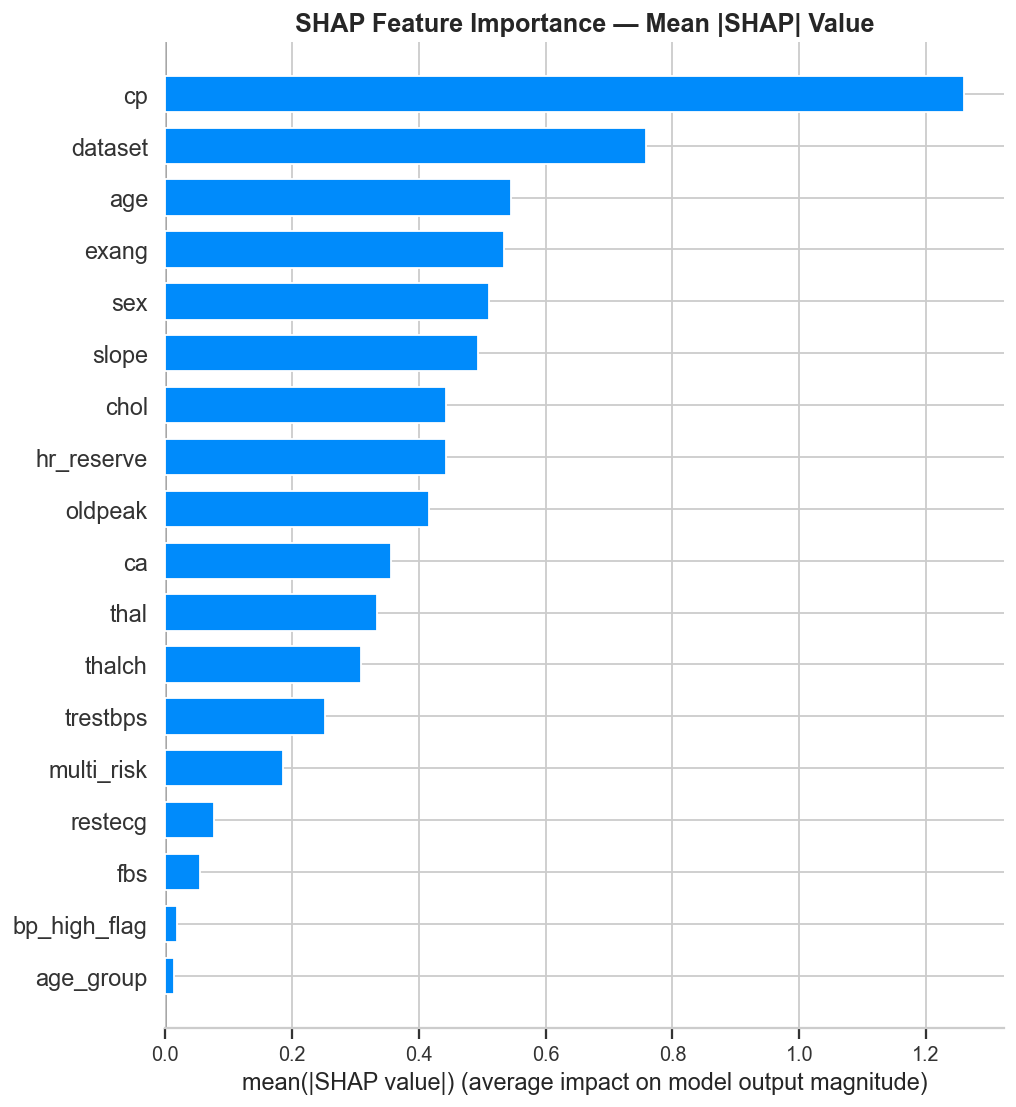

In [ ]:
# ── Fig 13: SHAP Bar Plot ─────────────────────────────────────────────────────
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, Xte.values[:100],
                  feature_names=list(X_eng.columns),
                  plot_type="bar", show=False)
plt.title("SHAP Feature Importance — Mean |SHAP| Value", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

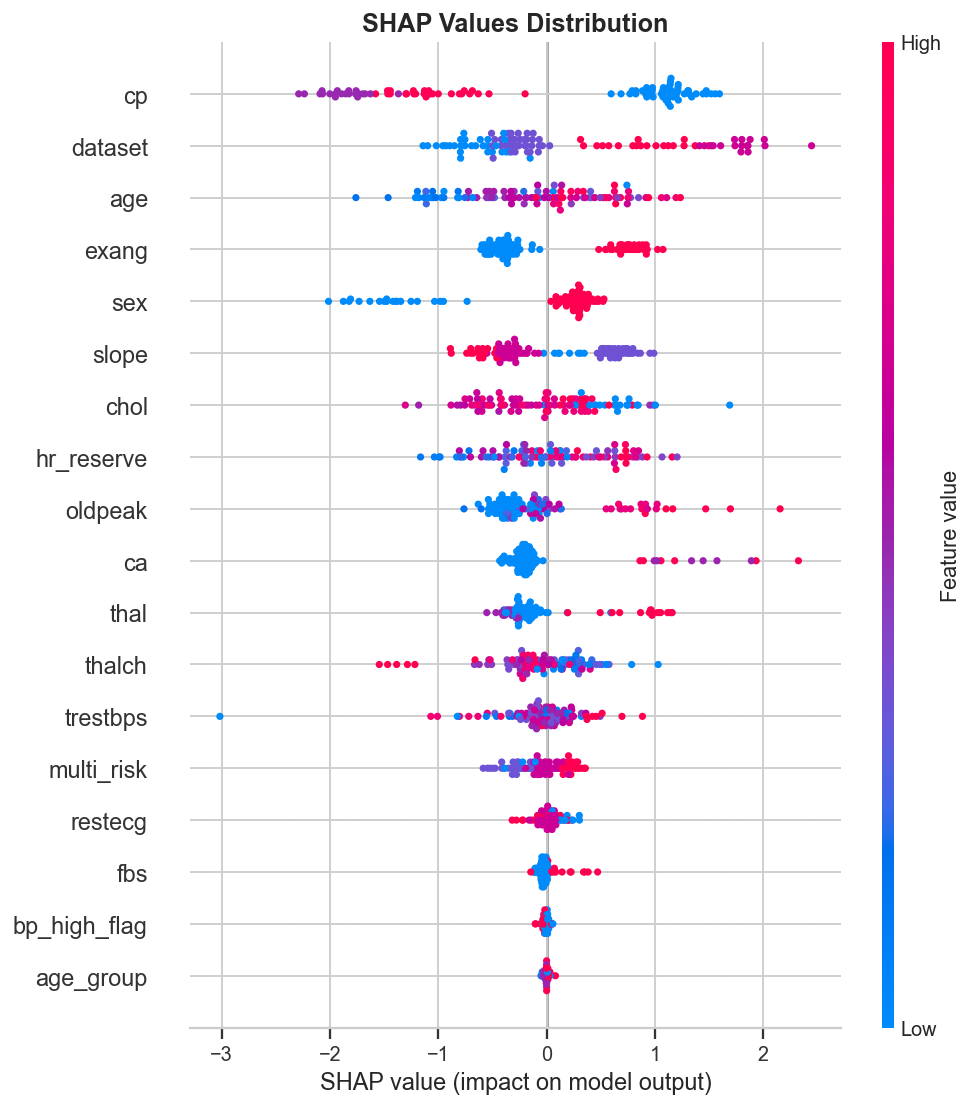

In [ ]:
# ── Fig 14: SHAP Beeswarm Plot ───────────────────────────────────────────────
shap.summary_plot(shap_values, Xte.values[:100],
                  feature_names=list(X_eng.columns),
                  show=False)
plt.title("SHAP Values Distribution", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

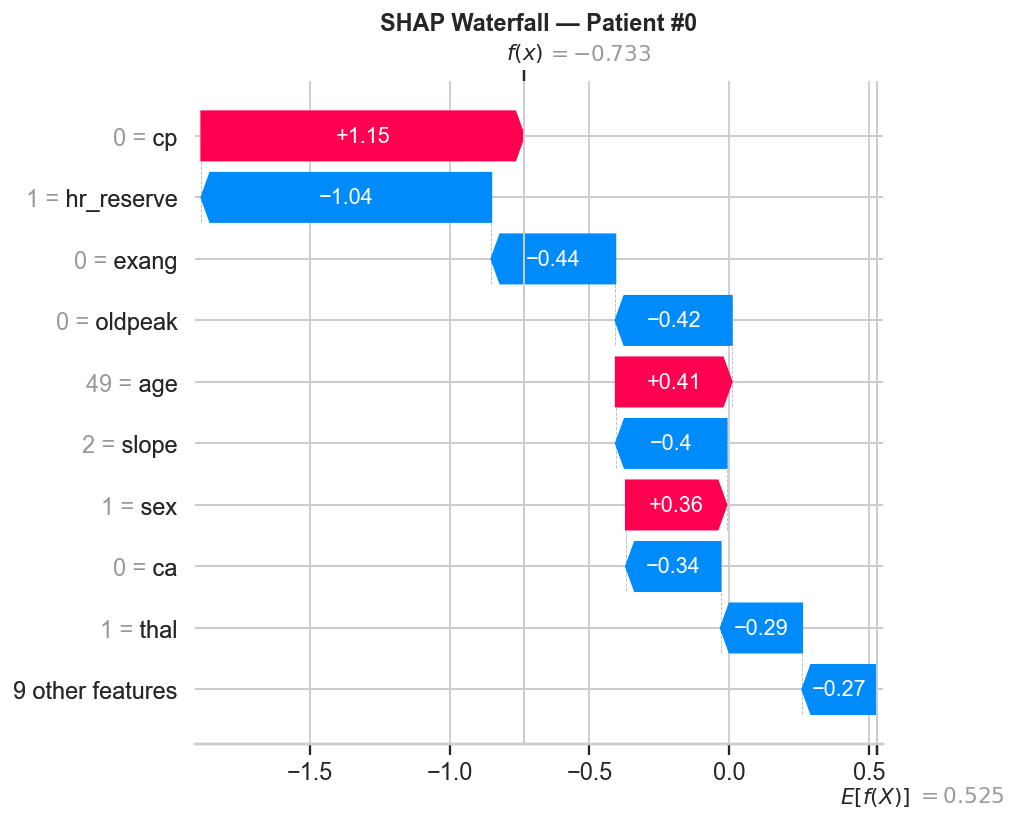

Patient #0: Actual=Disease | Predicted=No Disease


In [ ]:
# ── Fig 15: SHAP Waterfall — Single Patient ───────────────────────────────────
# شرح قرار النموذج لمريض واحد
patient_idx = 0
base_val = explainer.expected_value
if hasattr(base_val, '__len__'):
    base_val = float(base_val[0])
else:
    base_val = float(base_val)

shap.plots.waterfall(shap.Explanation(
    values        = shap_values[patient_idx],
    base_values   = base_val,
    data          = Xte.values[patient_idx],
    feature_names = list(X_eng.columns)
), show=False)
plt.title(f"SHAP Waterfall — Patient #{patient_idx}", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

actual    = "Disease" if yte.values[patient_idx] == 1 else "No Disease"
predicted = "Disease" if models["Gradient Boosting"].predict(Xte.values[patient_idx:patient_idx+1])[0] == 1 else "No Disease"
print(f"Patient #{patient_idx}: Actual={actual} | Predicted={predicted}")